In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

In [3]:
df=pd.read_csv(r"G:\vansh clg\Data Analysis Project\Relme.csv")

In [4]:
df

,Unnamed: 0,Company Name,Mobile Price,Offer Given,Specifications,Rating,Review
0,0,"realme 11x 5G (Purple Dawn, 128 GB)","₹15,999",15% off,8 GB RAM | 128 GB ROM | Expandable Upto 2 TB17...,4.3,"2,515 Ratings & 210 Reviews"
1,1,"realme 11x 5G (Purple Dawn, 128 GB)","₹14,999",NaN,6 GB RAM | 128 GB ROM | Expandable Upto 2 TB17...,4.4,"13,807 Ratings & 988 Reviews"
2,2,"realme 11x 5G (Midnight Black, 128 GB)","₹14,999",11% off,6 GB RAM | 128 GB ROM | Expandable Upto 2 TB17...,4.4,"13,807 Ratings & 988 Reviews"
3,3,"realme 11x 5G (Midnight Black, 128 GB)","₹15,999",15% off,8 GB RAM | 128 GB ROM | Expandable Upto 2 TB17...,4.3,"2,515 Ratings & 210 Reviews"
4,4,"realme C53 (Champion Gold, 64 GB)","₹10,999",NaN,6 GB RAM | 64 GB ROM | Expandable Upto 2 TB17....,4.4,"28,188 Ratings & 1,402 Reviews"
...,...,...,...,...,...,...,...
187,187,"realme 11 5G (Glory Black, 256 GB)","₹19,999",13% off,8 GB RAM | 256 GB ROM | Expandable Upto 2 TB17...,4.3,"6,015 Ratings & 597 Reviews"
188,188,"realme 11 5G (Glory Gold, 128 GB)","₹18,999",9% off,8 GB RAM | 128 GB ROM | Expandable Upto 2 TB17...,4.3,"6,015 Ratings & 597 Reviews"
189,189,"realme 11 5G (Glory Gold, 256 GB)","₹19,999",13% off,8 GB RAM | 256 GB ROM | Expandable Upto 2 TB17...,4.3,"6,015 Ratings & 597 Reviews"
190,190,"realme C53 (Champion Black, 128 GB)","₹11,999",14% off,6 GB RAM | 128 GB ROM | Expandable Upto 2 TB17...,4.4,"28,188 Ratings & 1,402 Reviews"


In [3]:
def extract_specs(text):
    specs = {
        "RAM": None,
        "ROM": None,
        "Display": None,
        "Camera": None,
        "Battery": None,
        "Processor": None,
        "Phone_Warranty": None,
        "Accessory_Warranty": None
    }

    # Regex patterns
    ram_match = re.search(r'(\d+\s*GB)\s*RAM', text, re.IGNORECASE)
    rom_match = re.search(r'(\d+\s*(?:GB|TB))\s*ROM', text, re.IGNORECASE)
    display_match = re.search(r'(\d+\.?\d*[-\s]?(?:inch|inches|cm)[^,|]*?display)', text, re.IGNORECASE)
    camera_match = re.search(r'(\d+MP.*?Camera)', text, re.IGNORECASE)
    battery_match = re.search(r'(\d+ ?mAh)', text, re.IGNORECASE)
    processor_match = re.search(r'(Helio|Dimensity|Snapdragon|Unisoc|Mediatek|Tiger)[^,|]*?Processor', text, re.IGNORECASE)
    phone_warranty_match = re.search(r'(\d+\s*(?:Year|Month)s?\s*Manufacturer Warranty for Phone)', text, re.IGNORECASE)
    accessory_warranty_match = re.search(r'(\d+\s*(?:Year|Month)s?\s*Warranty for In the Box Accessories)', text, re.IGNORECASE)

    # Assign values if found
    if ram_match: specs["RAM"] = ram_match.group(1)
    if rom_match: specs["ROM"] = rom_match.group(1)
    if display_match: specs["Display"] = display_match.group(1)
    if camera_match: specs["Camera"] = camera_match.group(1)
    if battery_match: specs["Battery"] = battery_match.group(1)
    if processor_match: specs["Processor"] = processor_match.group(0)
    if phone_warranty_match: specs["Phone_Warranty"] = phone_warranty_match.group(1)
    if accessory_warranty_match: specs["Accessory_Warranty"] = accessory_warranty_match.group(1)

    return pd.Series(specs)



In [4]:
df

,Unnamed: 0,Company Name,Mobile Price,Offer Given,Specifications,Rating,Review
0,0,"realme 11x 5G (Purple Dawn, 128 GB)","₹15,999",15% off,8 GB RAM | 128 GB ROM | Expandable Upto 2 TB17...,4.3,"2,515 Ratings & 210 Reviews"
1,1,"realme 11x 5G (Purple Dawn, 128 GB)","₹14,999",NaN,6 GB RAM | 128 GB ROM | Expandable Upto 2 TB17...,4.4,"13,807 Ratings & 988 Reviews"
2,2,"realme 11x 5G (Midnight Black, 128 GB)","₹14,999",11% off,6 GB RAM | 128 GB ROM | Expandable Upto 2 TB17...,4.4,"13,807 Ratings & 988 Reviews"
3,3,"realme 11x 5G (Midnight Black, 128 GB)","₹15,999",15% off,8 GB RAM | 128 GB ROM | Expandable Upto 2 TB17...,4.3,"2,515 Ratings & 210 Reviews"
4,4,"realme C53 (Champion Gold, 64 GB)","₹10,999",NaN,6 GB RAM | 64 GB ROM | Expandable Upto 2 TB17....,4.4,"28,188 Ratings & 1,402 Reviews"
...,...,...,...,...,...,...,...
187,187,"realme 11 5G (Glory Black, 256 GB)","₹19,999",13% off,8 GB RAM | 256 GB ROM | Expandable Upto 2 TB17...,4.3,"6,015 Ratings & 597 Reviews"
188,188,"realme 11 5G (Glory Gold, 128 GB)","₹18,999",9% off,8 GB RAM | 128 GB ROM | Expandable Upto 2 TB17...,4.3,"6,015 Ratings & 597 Reviews"
189,189,"realme 11 5G (Glory Gold, 256 GB)","₹19,999",13% off,8 GB RAM | 256 GB ROM | Expandable Upto 2 TB17...,4.3,"6,015 Ratings & 597 Reviews"
190,190,"realme C53 (Champion Black, 128 GB)","₹11,999",14% off,6 GB RAM | 128 GB ROM | Expandable Upto 2 TB17...,4.4,"28,188 Ratings & 1,402 Reviews"


In [5]:
df = pd.concat([df, df["Specifications"].apply(extract_specs)], axis=1)
df

,Unnamed: 0,Company Name,Mobile Price,Offer Given,Specifications,Rating,Review,RAM,ROM,Display,Camera,Battery,Processor,Phone_Warranty,Accessory_Warranty
0,0,"realme 11x 5G (Purple Dawn, 128 GB)","₹15,999",15% off,8 GB RAM | 128 GB ROM | Expandable Upto 2 TB17...,4.3,"2,515 Ratings & 210 Reviews",8 GB,128 GB,17.07 cm (6.72 inch) Full HD+ Display,64MP + 2MP | 8MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories
1,1,"realme 11x 5G (Purple Dawn, 128 GB)","₹14,999",NaN,6 GB RAM | 128 GB ROM | Expandable Upto 2 TB17...,4.4,"13,807 Ratings & 988 Reviews",6 GB,128 GB,17.07 cm (6.72 inch) Full HD+ Display,64MP + 2MP | 8MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories
2,2,"realme 11x 5G (Midnight Black, 128 GB)","₹14,999",11% off,6 GB RAM | 128 GB ROM | Expandable Upto 2 TB17...,4.4,"13,807 Ratings & 988 Reviews",6 GB,128 GB,17.07 cm (6.72 inch) Full HD+ Display,64MP + 2MP | 8MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories
3,3,"realme 11x 5G (Midnight Black, 128 GB)","₹15,999",15% off,8 GB RAM | 128 GB ROM | Expandable Upto 2 TB17...,4.3,"2,515 Ratings & 210 Reviews",8 GB,128 GB,17.07 cm (6.72 inch) Full HD+ Display,64MP + 2MP | 8MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories
4,4,"realme C53 (Champion Gold, 64 GB)","₹10,999",NaN,6 GB RAM | 64 GB ROM | Expandable Upto 2 TB17....,4.4,"28,188 Ratings & 1,402 Reviews",6 GB,64 GB,17.12 cm (6.74 inch) HD Display,108MP + 2MP | 8MP Front Camera,5000 mAh,None,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,187,"realme 11 5G (Glory Black, 256 GB)","₹19,999",13% off,8 GB RAM | 256 GB ROM | Expandable Upto 2 TB17...,4.3,"6,015 Ratings & 597 Reviews",8 GB,256 GB,17.07 cm (6.72 inch) Full HD+ Display,108MP + 2MP | 16MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories
188,188,"realme 11 5G (Glory Gold, 128 GB)","₹18,999",9% off,8 GB RAM | 128 GB ROM | Expandable Upto 2 TB17...,4.3,"6,015 Ratings & 597 Reviews",8 GB,128 GB,17.07 cm (6.72 inch) Full HD+ Display,108MP + 2MP | 16MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories
189,189,"realme 11 5G (Glory Gold, 256 GB)","₹19,999",13% off,8 GB RAM | 256 GB ROM | Expandable Upto 2 TB17...,4.3,"6,015 Ratings & 597 Reviews",8 GB,256 GB,17.07 cm (6.72 inch) Full HD+ Display,108MP + 2MP | 16MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories
190,190,"realme C53 (Champion Black, 128 GB)","₹11,999",14% off,6 GB RAM | 128 GB ROM | Expandable Upto 2 TB17...,4.4,"28,188 Ratings & 1,402 Reviews",6 GB,128 GB,17.12 cm (6.74 inch) HD Display,108MP + 2MP | 8MP Front Camera,5000 mAh,None,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories


In [6]:
df['Mobile Name'] = df['Company Name'].str.extract(r'^(.*?) \(')
df['Color'] = df['Company Name'].str.extract(r'\((.*?),')
df

,Unnamed: 0,Company Name,Mobile Price,Offer Given,Specifications,Rating,Review,RAM,ROM,Display,Camera,Battery,Processor,Phone_Warranty,Accessory_Warranty,Mobile Name,Color
0,0,"realme 11x 5G (Purple Dawn, 128 GB)","₹15,999",15% off,8 GB RAM | 128 GB ROM | Expandable Upto 2 TB17...,4.3,"2,515 Ratings & 210 Reviews",8 GB,128 GB,17.07 cm (6.72 inch) Full HD+ Display,64MP + 2MP | 8MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,realme 11x 5G,Purple Dawn
1,1,"realme 11x 5G (Purple Dawn, 128 GB)","₹14,999",NaN,6 GB RAM | 128 GB ROM | Expandable Upto 2 TB17...,4.4,"13,807 Ratings & 988 Reviews",6 GB,128 GB,17.07 cm (6.72 inch) Full HD+ Display,64MP + 2MP | 8MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,realme 11x 5G,Purple Dawn
2,2,"realme 11x 5G (Midnight Black, 128 GB)","₹14,999",11% off,6 GB RAM | 128 GB ROM | Expandable Upto 2 TB17...,4.4,"13,807 Ratings & 988 Reviews",6 GB,128 GB,17.07 cm (6.72 inch) Full HD+ Display,64MP + 2MP | 8MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,realme 11x 5G,Midnight Black
3,3,"realme 11x 5G (Midnight Black, 128 GB)","₹15,999",15% off,8 GB RAM | 128 GB ROM | Expandable Upto 2 TB17...,4.3,"2,515 Ratings & 210 Reviews",8 GB,128 GB,17.07 cm (6.72 inch) Full HD+ Display,64MP + 2MP | 8MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,realme 11x 5G,Midnight Black
4,4,"realme C53 (Champion Gold, 64 GB)","₹10,999",NaN,6 GB RAM | 64 GB ROM | Expandable Upto 2 TB17....,4.4,"28,188 Ratings & 1,402 Reviews",6 GB,64 GB,17.12 cm (6.74 inch) HD Display,108MP + 2MP | 8MP Front Camera,5000 mAh,None,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,realme C53,Champion Gold
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,187,"realme 11 5G (Glory Black, 256 GB)","₹19,999",13% off,8 GB RAM | 256 GB ROM | Expandable Upto 2 TB17...,4.3,"6,015 Ratings & 597 Reviews",8 GB,256 GB,17.07 cm (6.72 inch) Full HD+ Display,108MP + 2MP | 16MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,realme 11 5G,Glory Black
188,188,"realme 11 5G (Glory Gold, 128 GB)","₹18,999",9% off,8 GB RAM | 128 GB ROM | Expandable Upto 2 TB17...,4.3,"6,015 Ratings & 597 Reviews",8 GB,128 GB,17.07 cm (6.72 inch) Full HD+ Display,108MP + 2MP | 16MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,realme 11 5G,Glory Gold
189,189,"realme 11 5G (Glory Gold, 256 GB)","₹19,999",13% off,8 GB RAM | 256 GB ROM | Expandable Upto 2 TB17...,4.3,"6,015 Ratings & 597 Reviews",8 GB,256 GB,17.07 cm (6.72 inch) Full HD+ Display,108MP + 2MP | 16MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,realme 11 5G,Glory Gold
190,190,"realme C53 (Champion Black, 128 GB)","₹11,999",14% off,6 GB RAM | 128 GB ROM | Expandable Upto 2 TB17...,4.4,"28,188 Ratings & 1,402 Reviews",6 GB,128 GB,17.12 cm (6.74 inch) HD Display,108MP + 2MP | 8MP Front Camera,5000 mAh,None,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,realme C53,Champion Black


In [7]:
df['Ratings_Count'] = df['Review'].str.extract(r'([\d,]+)\s*Ratings', expand=False)
df['Reviews_Count'] = df['Review'].str.extract(r'([\d,]+)\s*Reviews', expand=False)
df['Ratings_Count'] = df['Ratings_Count'].str.replace(',', '', regex=True).astype(float)
df['Reviews_Count'] = df['Reviews_Count'].str.replace(',', '', regex=True).astype(float)
df

,Unnamed: 0,Company Name,Mobile Price,Offer Given,Specifications,Rating,Review,RAM,ROM,Display,Camera,Battery,Processor,Phone_Warranty,Accessory_Warranty,Mobile Name,Color,Ratings_Count,Reviews_Count
0,0,"realme 11x 5G (Purple Dawn, 128 GB)","₹15,999",15% off,8 GB RAM | 128 GB ROM | Expandable Upto 2 TB17...,4.3,"2,515 Ratings & 210 Reviews",8 GB,128 GB,17.07 cm (6.72 inch) Full HD+ Display,64MP + 2MP | 8MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,realme 11x 5G,Purple Dawn,2515.0,210.0
1,1,"realme 11x 5G (Purple Dawn, 128 GB)","₹14,999",NaN,6 GB RAM | 128 GB ROM | Expandable Upto 2 TB17...,4.4,"13,807 Ratings & 988 Reviews",6 GB,128 GB,17.07 cm (6.72 inch) Full HD+ Display,64MP + 2MP | 8MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,realme 11x 5G,Purple Dawn,13807.0,988.0
2,2,"realme 11x 5G (Midnight Black, 128 GB)","₹14,999",11% off,6 GB RAM | 128 GB ROM | Expandable Upto 2 TB17...,4.4,"13,807 Ratings & 988 Reviews",6 GB,128 GB,17.07 cm (6.72 inch) Full HD+ Display,64MP + 2MP | 8MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,realme 11x 5G,Midnight Black,13807.0,988.0
3,3,"realme 11x 5G (Midnight Black, 128 GB)","₹15,999",15% off,8 GB RAM | 128 GB ROM | Expandable Upto 2 TB17...,4.3,"2,515 Ratings & 210 Reviews",8 GB,128 GB,17.07 cm (6.72 inch) Full HD+ Display,64MP + 2MP | 8MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,realme 11x 5G,Midnight Black,2515.0,210.0
4,4,"realme C53 (Champion Gold, 64 GB)","₹10,999",NaN,6 GB RAM | 64 GB ROM | Expandable Upto 2 TB17....,4.4,"28,188 Ratings & 1,402 Reviews",6 GB,64 GB,17.12 cm (6.74 inch) HD Display,108MP + 2MP | 8MP Front Camera,5000 mAh,None,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,realme C53,Champion Gold,28188.0,1402.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,187,"realme 11 5G (Glory Black, 256 GB)","₹19,999",13% off,8 GB RAM | 256 GB ROM | Expandable Upto 2 TB17...,4.3,"6,015 Ratings & 597 Reviews",8 GB,256 GB,17.07 cm (6.72 inch) Full HD+ Display,108MP + 2MP | 16MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,realme 11 5G,Glory Black,6015.0,597.0
188,188,"realme 11 5G (Glory Gold, 128 GB)","₹18,999",9% off,8 GB RAM | 128 GB ROM | Expandable Upto 2 TB17...,4.3,"6,015 Ratings & 597 Reviews",8 GB,128 GB,17.07 cm (6.72 inch) Full HD+ Display,108MP + 2MP | 16MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,realme 11 5G,Glory Gold,6015.0,597.0
189,189,"realme 11 5G (Glory Gold, 256 GB)","₹19,999",13% off,8 GB RAM | 256 GB ROM | Expandable Upto 2 TB17...,4.3,"6,015 Ratings & 597 Reviews",8 GB,256 GB,17.07 cm (6.72 inch) Full HD+ Display,108MP + 2MP | 16MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,realme 11 5G,Glory Gold,6015.0,597.0
190,190,"realme C53 (Champion Black, 128 GB)","₹11,999",14% off,6 GB RAM | 128 GB ROM | Expandable Upto 2 TB17...,4.4,"28,188 Ratings & 1,402 Reviews",6 GB,128 GB,17.12 cm (6.74 inch) HD Display,108MP + 2MP | 8MP Front Camera,5000 mAh,None,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,realme C53,Champion Black,28188.0,1402.0


In [8]:
df.drop(columns=['Specifications', 'Review','Company Name'], inplace=True)
df

,Unnamed: 0,Mobile Price,Offer Given,Rating,RAM,ROM,Display,Camera,Battery,Processor,Phone_Warranty,Accessory_Warranty,Mobile Name,Color,Ratings_Count,Reviews_Count
0,0,"₹15,999",15% off,4.3,8 GB,128 GB,17.07 cm (6.72 inch) Full HD+ Display,64MP + 2MP | 8MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,realme 11x 5G,Purple Dawn,2515.0,210.0
1,1,"₹14,999",NaN,4.4,6 GB,128 GB,17.07 cm (6.72 inch) Full HD+ Display,64MP + 2MP | 8MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,realme 11x 5G,Purple Dawn,13807.0,988.0
2,2,"₹14,999",11% off,4.4,6 GB,128 GB,17.07 cm (6.72 inch) Full HD+ Display,64MP + 2MP | 8MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,realme 11x 5G,Midnight Black,13807.0,988.0
3,3,"₹15,999",15% off,4.3,8 GB,128 GB,17.07 cm (6.72 inch) Full HD+ Display,64MP + 2MP | 8MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,realme 11x 5G,Midnight Black,2515.0,210.0
4,4,"₹10,999",NaN,4.4,6 GB,64 GB,17.12 cm (6.74 inch) HD Display,108MP + 2MP | 8MP Front Camera,5000 mAh,None,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,realme C53,Champion Gold,28188.0,1402.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,187,"₹19,999",13% off,4.3,8 GB,256 GB,17.07 cm (6.72 inch) Full HD+ Display,108MP + 2MP | 16MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,realme 11 5G,Glory Black,6015.0,597.0
188,188,"₹18,999",9% off,4.3,8 GB,128 GB,17.07 cm (6.72 inch) Full HD+ Display,108MP + 2MP | 16MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,realme 11 5G,Glory Gold,6015.0,597.0
189,189,"₹19,999",13% off,4.3,8 GB,256 GB,17.07 cm (6.72 inch) Full HD+ Display,108MP + 2MP | 16MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,realme 11 5G,Glory Gold,6015.0,597.0
190,190,"₹11,999",14% off,4.4,6 GB,128 GB,17.12 cm (6.74 inch) HD Display,108MP + 2MP | 8MP Front Camera,5000 mAh,None,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,realme C53,Champion Black,28188.0,1402.0


In [9]:
new_order = [
    'Unnamed: 0', 'Mobile Name', 'Color', 'Mobile Price', 'Offer Given', 
    'RAM', 'ROM', 'Display', 'Camera', 'Battery', 'Processor', 
    'Phone_Warranty', 'Accessory_Warranty', 'Rating', 'Ratings_Count', 'Reviews_Count'
]


df = df[new_order]
df

,Unnamed: 0,Mobile Name,Color,Mobile Price,Offer Given,RAM,ROM,Display,Camera,Battery,Processor,Phone_Warranty,Accessory_Warranty,Rating,Ratings_Count,Reviews_Count
0,0,realme 11x 5G,Purple Dawn,"₹15,999",15% off,8 GB,128 GB,17.07 cm (6.72 inch) Full HD+ Display,64MP + 2MP | 8MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.3,2515.0,210.0
1,1,realme 11x 5G,Purple Dawn,"₹14,999",NaN,6 GB,128 GB,17.07 cm (6.72 inch) Full HD+ Display,64MP + 2MP | 8MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.4,13807.0,988.0
2,2,realme 11x 5G,Midnight Black,"₹14,999",11% off,6 GB,128 GB,17.07 cm (6.72 inch) Full HD+ Display,64MP + 2MP | 8MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.4,13807.0,988.0
3,3,realme 11x 5G,Midnight Black,"₹15,999",15% off,8 GB,128 GB,17.07 cm (6.72 inch) Full HD+ Display,64MP + 2MP | 8MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.3,2515.0,210.0
4,4,realme C53,Champion Gold,"₹10,999",NaN,6 GB,64 GB,17.12 cm (6.74 inch) HD Display,108MP + 2MP | 8MP Front Camera,5000 mAh,None,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.4,28188.0,1402.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,187,realme 11 5G,Glory Black,"₹19,999",13% off,8 GB,256 GB,17.07 cm (6.72 inch) Full HD+ Display,108MP + 2MP | 16MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.3,6015.0,597.0
188,188,realme 11 5G,Glory Gold,"₹18,999",9% off,8 GB,128 GB,17.07 cm (6.72 inch) Full HD+ Display,108MP + 2MP | 16MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.3,6015.0,597.0
189,189,realme 11 5G,Glory Gold,"₹19,999",13% off,8 GB,256 GB,17.07 cm (6.72 inch) Full HD+ Display,108MP + 2MP | 16MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.3,6015.0,597.0
190,190,realme C53,Champion Black,"₹11,999",14% off,6 GB,128 GB,17.12 cm (6.74 inch) HD Display,108MP + 2MP | 8MP Front Camera,5000 mAh,None,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.4,28188.0,1402.0


In [10]:
df.describe()

,Unnamed: 0,Rating,Ratings_Count,Reviews_Count
count,192.000000,192.000000,192.000000,192.000000
mean,95.500000,4.308333,18650.354167,1498.635417
std,55.569776,0.076119,11702.820950,988.524842
min,0.000000,4.100000,939.000000,82.000000
25%,47.750000,4.300000,9040.000000,976.000000
50%,95.500000,4.300000,13807.000000,999.000000
75%,143.250000,4.325000,28188.000000,2677.000000
max,191.000000,4.400000,38372.000000,3041.000000


In [11]:
df.columns

Index(['Unnamed: 0', 'Mobile Name', 'Color', 'Mobile Price', 'Offer Given',
       'RAM', 'ROM', 'Display', 'Camera', 'Battery', 'Processor',
       'Phone_Warranty', 'Accessory_Warranty', 'Rating', 'Ratings_Count',
       'Reviews_Count'],
      dtype='object')

In [12]:
df.head()

,Unnamed: 0,Mobile Name,Color,Mobile Price,Offer Given,RAM,ROM,Display,Camera,Battery,Processor,Phone_Warranty,Accessory_Warranty,Rating,Ratings_Count,Reviews_Count
0,0,realme 11x 5G,Purple Dawn,"₹15,999",15% off,8 GB,128 GB,17.07 cm (6.72 inch) Full HD+ Display,64MP + 2MP | 8MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.3,2515.0,210.0
1,1,realme 11x 5G,Purple Dawn,"₹14,999",NaN,6 GB,128 GB,17.07 cm (6.72 inch) Full HD+ Display,64MP + 2MP | 8MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.4,13807.0,988.0
2,2,realme 11x 5G,Midnight Black,"₹14,999",11% off,6 GB,128 GB,17.07 cm (6.72 inch) Full HD+ Display,64MP + 2MP | 8MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.4,13807.0,988.0
3,3,realme 11x 5G,Midnight Black,"₹15,999",15% off,8 GB,128 GB,17.07 cm (6.72 inch) Full HD+ Display,64MP + 2MP | 8MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.3,2515.0,210.0
4,4,realme C53,Champion Gold,"₹10,999",NaN,6 GB,64 GB,17.12 cm (6.74 inch) HD Display,108MP + 2MP | 8MP Front Camera,5000 mAh,None,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.4,28188.0,1402.0


In [13]:
df.tail()

,Unnamed: 0,Mobile Name,Color,Mobile Price,Offer Given,RAM,ROM,Display,Camera,Battery,Processor,Phone_Warranty,Accessory_Warranty,Rating,Ratings_Count,Reviews_Count
187,187,realme 11 5G,Glory Black,"₹19,999",13% off,8 GB,256 GB,17.07 cm (6.72 inch) Full HD+ Display,108MP + 2MP | 16MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.3,6015.0,597.0
188,188,realme 11 5G,Glory Gold,"₹18,999",9% off,8 GB,128 GB,17.07 cm (6.72 inch) Full HD+ Display,108MP + 2MP | 16MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.3,6015.0,597.0
189,189,realme 11 5G,Glory Gold,"₹19,999",13% off,8 GB,256 GB,17.07 cm (6.72 inch) Full HD+ Display,108MP + 2MP | 16MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.3,6015.0,597.0
190,190,realme C53,Champion Black,"₹11,999",14% off,6 GB,128 GB,17.12 cm (6.74 inch) HD Display,108MP + 2MP | 8MP Front Camera,5000 mAh,None,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.4,28188.0,1402.0
191,191,realme C53,Champion Gold,"₹11,999",14% off,6 GB,128 GB,17.12 cm (6.74 inch) HD Display,108MP + 2MP | 8MP Front Camera,5000 mAh,None,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.4,28188.0,1402.0


In [14]:
df.isnull().sum()

Unnamed: 0             0
Mobile Name            0
Color                  0
Mobile Price           0
Offer Given           16
RAM                    0
ROM                    0
Display                0
Camera                 0
Battery                0
Processor             48
Phone_Warranty        84
Accessory_Warranty    94
Rating                 0
Ratings_Count          0
Reviews_Count          0
dtype: int64

In [15]:
df.duplicated().sum()

0

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 192 entries, 0 to 191
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          192 non-null    int64  
 1   Mobile Name         192 non-null    object 
 2   Color               192 non-null    object 
 3   Mobile Price        192 non-null    object 
 4   Offer Given         176 non-null    object 
 5   RAM                 192 non-null    object 
 6   ROM                 192 non-null    object 
 7   Display             192 non-null    object 
 8   Camera              192 non-null    object 
 9   Battery             192 non-null    object 
 10  Processor           144 non-null    object 
 11  Phone_Warranty      108 non-null    object 
 12  Accessory_Warranty  98 non-null     object 
 13  Rating              192 non-null    float64
 14  Ratings_Count       192 non-null    float64
 15  Reviews_Count       192 non-null    float64
dtypes: float

In [17]:
df['Unnamed: 0']=df['Unnamed: 0']+1
df = df.rename(columns={'Unnamed: 0': 'SNumber'})
df

,SNumber,Mobile Name,Color,Mobile Price,Offer Given,RAM,ROM,Display,Camera,Battery,Processor,Phone_Warranty,Accessory_Warranty,Rating,Ratings_Count,Reviews_Count
0,1,realme 11x 5G,Purple Dawn,"₹15,999",15% off,8 GB,128 GB,17.07 cm (6.72 inch) Full HD+ Display,64MP + 2MP | 8MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.3,2515.0,210.0
1,2,realme 11x 5G,Purple Dawn,"₹14,999",NaN,6 GB,128 GB,17.07 cm (6.72 inch) Full HD+ Display,64MP + 2MP | 8MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.4,13807.0,988.0
2,3,realme 11x 5G,Midnight Black,"₹14,999",11% off,6 GB,128 GB,17.07 cm (6.72 inch) Full HD+ Display,64MP + 2MP | 8MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.4,13807.0,988.0
3,4,realme 11x 5G,Midnight Black,"₹15,999",15% off,8 GB,128 GB,17.07 cm (6.72 inch) Full HD+ Display,64MP + 2MP | 8MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.3,2515.0,210.0
4,5,realme C53,Champion Gold,"₹10,999",NaN,6 GB,64 GB,17.12 cm (6.74 inch) HD Display,108MP + 2MP | 8MP Front Camera,5000 mAh,None,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.4,28188.0,1402.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,188,realme 11 5G,Glory Black,"₹19,999",13% off,8 GB,256 GB,17.07 cm (6.72 inch) Full HD+ Display,108MP + 2MP | 16MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.3,6015.0,597.0
188,189,realme 11 5G,Glory Gold,"₹18,999",9% off,8 GB,128 GB,17.07 cm (6.72 inch) Full HD+ Display,108MP + 2MP | 16MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.3,6015.0,597.0
189,190,realme 11 5G,Glory Gold,"₹19,999",13% off,8 GB,256 GB,17.07 cm (6.72 inch) Full HD+ Display,108MP + 2MP | 16MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.3,6015.0,597.0
190,191,realme C53,Champion Black,"₹11,999",14% off,6 GB,128 GB,17.12 cm (6.74 inch) HD Display,108MP + 2MP | 8MP Front Camera,5000 mAh,None,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.4,28188.0,1402.0


In [18]:
df['Mobile Price'] = df['Mobile Price'].replace('[₹,]', '', regex=True).astype(float)
df

,SNumber,Mobile Name,Color,Mobile Price,Offer Given,RAM,ROM,Display,Camera,Battery,Processor,Phone_Warranty,Accessory_Warranty,Rating,Ratings_Count,Reviews_Count
0,1,realme 11x 5G,Purple Dawn,15999.0,15% off,8 GB,128 GB,17.07 cm (6.72 inch) Full HD+ Display,64MP + 2MP | 8MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.3,2515.0,210.0
1,2,realme 11x 5G,Purple Dawn,14999.0,NaN,6 GB,128 GB,17.07 cm (6.72 inch) Full HD+ Display,64MP + 2MP | 8MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.4,13807.0,988.0
2,3,realme 11x 5G,Midnight Black,14999.0,11% off,6 GB,128 GB,17.07 cm (6.72 inch) Full HD+ Display,64MP + 2MP | 8MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.4,13807.0,988.0
3,4,realme 11x 5G,Midnight Black,15999.0,15% off,8 GB,128 GB,17.07 cm (6.72 inch) Full HD+ Display,64MP + 2MP | 8MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.3,2515.0,210.0
4,5,realme C53,Champion Gold,10999.0,NaN,6 GB,64 GB,17.12 cm (6.74 inch) HD Display,108MP + 2MP | 8MP Front Camera,5000 mAh,None,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.4,28188.0,1402.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,188,realme 11 5G,Glory Black,19999.0,13% off,8 GB,256 GB,17.07 cm (6.72 inch) Full HD+ Display,108MP + 2MP | 16MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.3,6015.0,597.0
188,189,realme 11 5G,Glory Gold,18999.0,9% off,8 GB,128 GB,17.07 cm (6.72 inch) Full HD+ Display,108MP + 2MP | 16MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.3,6015.0,597.0
189,190,realme 11 5G,Glory Gold,19999.0,13% off,8 GB,256 GB,17.07 cm (6.72 inch) Full HD+ Display,108MP + 2MP | 16MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.3,6015.0,597.0
190,191,realme C53,Champion Black,11999.0,14% off,6 GB,128 GB,17.12 cm (6.74 inch) HD Display,108MP + 2MP | 8MP Front Camera,5000 mAh,None,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.4,28188.0,1402.0


In [19]:
df['Offer Given'] = df['Offer Given'].fillna(0)
df

,SNumber,Mobile Name,Color,Mobile Price,Offer Given,RAM,ROM,Display,Camera,Battery,Processor,Phone_Warranty,Accessory_Warranty,Rating,Ratings_Count,Reviews_Count
0,1,realme 11x 5G,Purple Dawn,15999.0,15% off,8 GB,128 GB,17.07 cm (6.72 inch) Full HD+ Display,64MP + 2MP | 8MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.3,2515.0,210.0
1,2,realme 11x 5G,Purple Dawn,14999.0,0,6 GB,128 GB,17.07 cm (6.72 inch) Full HD+ Display,64MP + 2MP | 8MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.4,13807.0,988.0
2,3,realme 11x 5G,Midnight Black,14999.0,11% off,6 GB,128 GB,17.07 cm (6.72 inch) Full HD+ Display,64MP + 2MP | 8MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.4,13807.0,988.0
3,4,realme 11x 5G,Midnight Black,15999.0,15% off,8 GB,128 GB,17.07 cm (6.72 inch) Full HD+ Display,64MP + 2MP | 8MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.3,2515.0,210.0
4,5,realme C53,Champion Gold,10999.0,0,6 GB,64 GB,17.12 cm (6.74 inch) HD Display,108MP + 2MP | 8MP Front Camera,5000 mAh,None,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.4,28188.0,1402.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,188,realme 11 5G,Glory Black,19999.0,13% off,8 GB,256 GB,17.07 cm (6.72 inch) Full HD+ Display,108MP + 2MP | 16MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.3,6015.0,597.0
188,189,realme 11 5G,Glory Gold,18999.0,9% off,8 GB,128 GB,17.07 cm (6.72 inch) Full HD+ Display,108MP + 2MP | 16MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.3,6015.0,597.0
189,190,realme 11 5G,Glory Gold,19999.0,13% off,8 GB,256 GB,17.07 cm (6.72 inch) Full HD+ Display,108MP + 2MP | 16MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.3,6015.0,597.0
190,191,realme C53,Champion Black,11999.0,14% off,6 GB,128 GB,17.12 cm (6.74 inch) HD Display,108MP + 2MP | 8MP Front Camera,5000 mAh,None,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.4,28188.0,1402.0


In [20]:
df = df.dropna(subset=["Processor"]).reset_index(drop=True)
df['Phone_Warranty'] = df['Phone_Warranty'].fillna("No Warranty")
df['Accessory_Warranty'] = df['Accessory_Warranty'].fillna("No Warranty")

In [21]:
df

,SNumber,Mobile Name,Color,Mobile Price,Offer Given,RAM,ROM,Display,Camera,Battery,Processor,Phone_Warranty,Accessory_Warranty,Rating,Ratings_Count,Reviews_Count
0,1,realme 11x 5G,Purple Dawn,15999.0,15% off,8 GB,128 GB,17.07 cm (6.72 inch) Full HD+ Display,64MP + 2MP | 8MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.3,2515.0,210.0
1,2,realme 11x 5G,Purple Dawn,14999.0,0,6 GB,128 GB,17.07 cm (6.72 inch) Full HD+ Display,64MP + 2MP | 8MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.4,13807.0,988.0
2,3,realme 11x 5G,Midnight Black,14999.0,11% off,6 GB,128 GB,17.07 cm (6.72 inch) Full HD+ Display,64MP + 2MP | 8MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.4,13807.0,988.0
3,4,realme 11x 5G,Midnight Black,15999.0,15% off,8 GB,128 GB,17.07 cm (6.72 inch) Full HD+ Display,64MP + 2MP | 8MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.3,2515.0,210.0
4,7,realme 11 Pro+ 5G,Oasis Green,29999.0,9% off,12 GB,256 GB,17.02 cm (6.7 inch) Full HD+ Display,200MP (OIS) + 8MP + 2MP | 32MP Front Camera,5000 mAh,Dimensity 7050 Processor,No Warranty,No Warranty,4.3,9040.0,976.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,186,realme 11 Pro+ 5G,Sunrise Beige,27999.0,6% off,8 GB,256 GB,17.02 cm (6.7 inch) Full HD+ Display,200MP (OIS) + 8MP + 2MP | 32MP Front Camera,5000 mAh,Dimensity 7050 Processor,No Warranty,No Warranty,4.3,25055.0,2677.0
140,187,realme 11 Pro+ 5G,Astral Black,27999.0,6% off,8 GB,256 GB,17.02 cm (6.7 inch) Full HD+ Display,200MP (OIS) + 8MP + 2MP | 32MP Front Camera,5000 mAh,Dimensity 7050 Processor,No Warranty,No Warranty,4.3,25055.0,2677.0
141,188,realme 11 5G,Glory Black,19999.0,13% off,8 GB,256 GB,17.07 cm (6.72 inch) Full HD+ Display,108MP + 2MP | 16MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.3,6015.0,597.0
142,189,realme 11 5G,Glory Gold,18999.0,9% off,8 GB,128 GB,17.07 cm (6.72 inch) Full HD+ Display,108MP + 2MP | 16MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.3,6015.0,597.0


In [22]:
df['RAM'] = df['RAM'].replace('[GB]', '', regex=True).astype(float)
df

,SNumber,Mobile Name,Color,Mobile Price,Offer Given,RAM,ROM,Display,Camera,Battery,Processor,Phone_Warranty,Accessory_Warranty,Rating,Ratings_Count,Reviews_Count
0,1,realme 11x 5G,Purple Dawn,15999.0,15% off,8.0,128 GB,17.07 cm (6.72 inch) Full HD+ Display,64MP + 2MP | 8MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.3,2515.0,210.0
1,2,realme 11x 5G,Purple Dawn,14999.0,0,6.0,128 GB,17.07 cm (6.72 inch) Full HD+ Display,64MP + 2MP | 8MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.4,13807.0,988.0
2,3,realme 11x 5G,Midnight Black,14999.0,11% off,6.0,128 GB,17.07 cm (6.72 inch) Full HD+ Display,64MP + 2MP | 8MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.4,13807.0,988.0
3,4,realme 11x 5G,Midnight Black,15999.0,15% off,8.0,128 GB,17.07 cm (6.72 inch) Full HD+ Display,64MP + 2MP | 8MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.3,2515.0,210.0
4,7,realme 11 Pro+ 5G,Oasis Green,29999.0,9% off,12.0,256 GB,17.02 cm (6.7 inch) Full HD+ Display,200MP (OIS) + 8MP + 2MP | 32MP Front Camera,5000 mAh,Dimensity 7050 Processor,No Warranty,No Warranty,4.3,9040.0,976.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,186,realme 11 Pro+ 5G,Sunrise Beige,27999.0,6% off,8.0,256 GB,17.02 cm (6.7 inch) Full HD+ Display,200MP (OIS) + 8MP + 2MP | 32MP Front Camera,5000 mAh,Dimensity 7050 Processor,No Warranty,No Warranty,4.3,25055.0,2677.0
140,187,realme 11 Pro+ 5G,Astral Black,27999.0,6% off,8.0,256 GB,17.02 cm (6.7 inch) Full HD+ Display,200MP (OIS) + 8MP + 2MP | 32MP Front Camera,5000 mAh,Dimensity 7050 Processor,No Warranty,No Warranty,4.3,25055.0,2677.0
141,188,realme 11 5G,Glory Black,19999.0,13% off,8.0,256 GB,17.07 cm (6.72 inch) Full HD+ Display,108MP + 2MP | 16MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.3,6015.0,597.0
142,189,realme 11 5G,Glory Gold,18999.0,9% off,8.0,128 GB,17.07 cm (6.72 inch) Full HD+ Display,108MP + 2MP | 16MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.3,6015.0,597.0


In [24]:
df['ROM'] = df['ROM'].replace('[GB]', '', regex=True).astype(float)
df

,SNumber,Mobile Name,Color,Mobile Price,Offer Given,RAM,ROM,Display,Camera,Battery,Processor,Phone_Warranty,Accessory_Warranty,Rating,Ratings_Count,Reviews_Count
0,1,realme 11x 5G,Purple Dawn,15999.0,15% off,8.0,128.0,17.07 cm (6.72 inch) Full HD+ Display,64MP + 2MP | 8MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.3,2515.0,210.0
1,2,realme 11x 5G,Purple Dawn,14999.0,0,6.0,128.0,17.07 cm (6.72 inch) Full HD+ Display,64MP + 2MP | 8MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.4,13807.0,988.0
2,3,realme 11x 5G,Midnight Black,14999.0,11% off,6.0,128.0,17.07 cm (6.72 inch) Full HD+ Display,64MP + 2MP | 8MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.4,13807.0,988.0
3,4,realme 11x 5G,Midnight Black,15999.0,15% off,8.0,128.0,17.07 cm (6.72 inch) Full HD+ Display,64MP + 2MP | 8MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.3,2515.0,210.0
4,7,realme 11 Pro+ 5G,Oasis Green,29999.0,9% off,12.0,256.0,17.02 cm (6.7 inch) Full HD+ Display,200MP (OIS) + 8MP + 2MP | 32MP Front Camera,5000 mAh,Dimensity 7050 Processor,No Warranty,No Warranty,4.3,9040.0,976.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,186,realme 11 Pro+ 5G,Sunrise Beige,27999.0,6% off,8.0,256.0,17.02 cm (6.7 inch) Full HD+ Display,200MP (OIS) + 8MP + 2MP | 32MP Front Camera,5000 mAh,Dimensity 7050 Processor,No Warranty,No Warranty,4.3,25055.0,2677.0
140,187,realme 11 Pro+ 5G,Astral Black,27999.0,6% off,8.0,256.0,17.02 cm (6.7 inch) Full HD+ Display,200MP (OIS) + 8MP + 2MP | 32MP Front Camera,5000 mAh,Dimensity 7050 Processor,No Warranty,No Warranty,4.3,25055.0,2677.0
141,188,realme 11 5G,Glory Black,19999.0,13% off,8.0,256.0,17.07 cm (6.72 inch) Full HD+ Display,108MP + 2MP | 16MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.3,6015.0,597.0
142,189,realme 11 5G,Glory Gold,18999.0,9% off,8.0,128.0,17.07 cm (6.72 inch) Full HD+ Display,108MP + 2MP | 16MP Front Camera,5000 mAh,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.3,6015.0,597.0


In [78]:
df['Battery'] = df['Battery'].replace('[mAh]', '', regex=True).astype(float)
df

,SNumber,Mobile Name,Color,Mobile Price,Offer Given,RAM,ROM,Display,Camera,Battery,Processor,Phone_Warranty,Accessory_Warranty,Rating,Ratings_Count,Reviews_Count
0,1,realme 11x 5G,Purple Dawn,15999.0,15.0,8.0,128.0,17.07 cm (6.72 inch) Full HD+ Display,64MP + 2MP | 8MP Front Camera,5000.0,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.3,2515.0,210.0
1,2,realme 11x 5G,Purple Dawn,14999.0,0.0,6.0,128.0,17.07 cm (6.72 inch) Full HD+ Display,64MP + 2MP | 8MP Front Camera,5000.0,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.4,13807.0,988.0
2,3,realme 11x 5G,Midnight Black,14999.0,11.0,6.0,128.0,17.07 cm (6.72 inch) Full HD+ Display,64MP + 2MP | 8MP Front Camera,5000.0,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.4,13807.0,988.0
3,4,realme 11x 5G,Midnight Black,15999.0,15.0,8.0,128.0,17.07 cm (6.72 inch) Full HD+ Display,64MP + 2MP | 8MP Front Camera,5000.0,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.3,2515.0,210.0
4,7,realme 11 Pro+ 5G,Oasis Green,29999.0,9.0,12.0,256.0,17.02 cm (6.7 inch) Full HD+ Display,200MP (OIS) + 8MP + 2MP | 32MP Front Camera,5000.0,Dimensity 7050 Processor,No Warranty,No Warranty,4.3,9040.0,976.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,186,realme 11 Pro+ 5G,Sunrise Beige,27999.0,6.0,8.0,256.0,17.02 cm (6.7 inch) Full HD+ Display,200MP (OIS) + 8MP + 2MP | 32MP Front Camera,5000.0,Dimensity 7050 Processor,No Warranty,No Warranty,4.3,25055.0,2677.0
140,187,realme 11 Pro+ 5G,Astral Black,27999.0,6.0,8.0,256.0,17.02 cm (6.7 inch) Full HD+ Display,200MP (OIS) + 8MP + 2MP | 32MP Front Camera,5000.0,Dimensity 7050 Processor,No Warranty,No Warranty,4.3,25055.0,2677.0
141,188,realme 11 5G,Glory Black,19999.0,13.0,8.0,256.0,17.07 cm (6.72 inch) Full HD+ Display,108MP + 2MP | 16MP Front Camera,5000.0,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.3,6015.0,597.0
142,189,realme 11 5G,Glory Gold,18999.0,9.0,8.0,128.0,17.07 cm (6.72 inch) Full HD+ Display,108MP + 2MP | 16MP Front Camera,5000.0,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.3,6015.0,597.0


In [26]:
df['Offer Given'] = df['Offer Given'].replace({'% off':'','%off':'','%':'','off':''}, regex=True).astype(float)
df

,SNumber,Mobile Name,Color,Mobile Price,Offer Given,RAM,ROM,Display,Camera,Battery,Processor,Phone_Warranty,Accessory_Warranty,Rating,Ratings_Count,Reviews_Count
0,1,realme 11x 5G,Purple Dawn,15999.0,15.0,8.0,128.0,17.07 cm (6.72 inch) Full HD+ Display,64MP + 2MP | 8MP Front Camera,5000.0,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.3,2515.0,210.0
1,2,realme 11x 5G,Purple Dawn,14999.0,0.0,6.0,128.0,17.07 cm (6.72 inch) Full HD+ Display,64MP + 2MP | 8MP Front Camera,5000.0,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.4,13807.0,988.0
2,3,realme 11x 5G,Midnight Black,14999.0,11.0,6.0,128.0,17.07 cm (6.72 inch) Full HD+ Display,64MP + 2MP | 8MP Front Camera,5000.0,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.4,13807.0,988.0
3,4,realme 11x 5G,Midnight Black,15999.0,15.0,8.0,128.0,17.07 cm (6.72 inch) Full HD+ Display,64MP + 2MP | 8MP Front Camera,5000.0,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.3,2515.0,210.0
4,7,realme 11 Pro+ 5G,Oasis Green,29999.0,9.0,12.0,256.0,17.02 cm (6.7 inch) Full HD+ Display,200MP (OIS) + 8MP + 2MP | 32MP Front Camera,5000.0,Dimensity 7050 Processor,No Warranty,No Warranty,4.3,9040.0,976.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,186,realme 11 Pro+ 5G,Sunrise Beige,27999.0,6.0,8.0,256.0,17.02 cm (6.7 inch) Full HD+ Display,200MP (OIS) + 8MP + 2MP | 32MP Front Camera,5000.0,Dimensity 7050 Processor,No Warranty,No Warranty,4.3,25055.0,2677.0
140,187,realme 11 Pro+ 5G,Astral Black,27999.0,6.0,8.0,256.0,17.02 cm (6.7 inch) Full HD+ Display,200MP (OIS) + 8MP + 2MP | 32MP Front Camera,5000.0,Dimensity 7050 Processor,No Warranty,No Warranty,4.3,25055.0,2677.0
141,188,realme 11 5G,Glory Black,19999.0,13.0,8.0,256.0,17.07 cm (6.72 inch) Full HD+ Display,108MP + 2MP | 16MP Front Camera,5000.0,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.3,6015.0,597.0
142,189,realme 11 5G,Glory Gold,18999.0,9.0,8.0,128.0,17.07 cm (6.72 inch) Full HD+ Display,108MP + 2MP | 16MP Front Camera,5000.0,Dimensity 6100+ Processor,1 Year Manufacturer Warranty for Phone,6 Months Warranty for In the Box Accessories,4.3,6015.0,597.0


In [103]:
top_rated = df.sort_values(by='Rating', ascending=False).head(5)[['Mobile Name','Rating','Mobile Price','Offer Given']]
top_rated

,Mobile Name,Rating,Mobile Price,Offer Given
38,realme 11x 5G,4.4,14999.0,11.0
37,realme 11x 5G,4.4,14999.0,0.0
92,realme 11x 5G,4.4,14999.0,11.0
91,realme 11x 5G,4.4,14999.0,0.0
20,realme 11x 5G,4.4,14999.0,11.0


In [104]:
df['Mobile Price'].describe()

count      144.000000
mean     23137.888889
std       5499.664467
min      14999.000000
25%      17749.000000
50%      24999.000000
75%      27999.000000
max      29999.000000
Name: Mobile Price, dtype: float64

In [36]:
df['Offer Given'].describe()


count    144.000000
mean       9.958333
std        4.457845
min        0.000000
25%        7.000000
50%        9.000000
75%       13.000000
max       21.000000
Name: Offer Given, dtype: float64

In [37]:
df[['RAM','ROM']].describe()


,RAM,ROM
count,144.000000,144.000000
mean,8.611111,208.000000
std,1.940049,62.184026
min,6.000000,128.000000
25%,8.000000,128.000000
50%,8.000000,256.000000
75%,8.000000,256.000000
max,12.000000,256.000000


In [38]:
df[['Rating','Ratings_Count','Reviews_Count']].describe()


,Rating,Ratings_Count,Reviews_Count
count,144.000000,144.000000,144.00000
mean,4.311111,17180.250000,1575.62500
std,0.031537,12512.915885,1126.58621
min,4.300000,939.000000,82.00000
25%,4.300000,6015.000000,597.00000
50%,4.300000,13807.000000,988.00000
75%,4.300000,32598.000000,2677.00000
max,4.400000,38372.000000,3041.00000


In [79]:
corr = df[['Mobile Price', 'Offer Given', 'RAM', 'ROM','Rating', 'Ratings_Count', 'Reviews_Count']].corr()
corr


,Mobile Price,Offer Given,RAM,ROM,Battery,Rating,Ratings_Count,Reviews_Count
Mobile Price,1.000000,-0.375132,0.726052,0.836238,NaN,-0.525046,0.150639,0.308018
Offer Given,-0.375132,1.000000,-0.042316,-0.284961,NaN,-0.354826,-0.024838,-0.146053
RAM,0.726052,-0.042316,1.000000,0.541633,NaN,-0.477508,-0.411238,-0.330086
ROM,0.836238,-0.284961,0.541633,1.000000,NaN,-0.456435,0.090568,0.240205
Battery,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rating,-0.525046,-0.354826,-0.477508,-0.456435,NaN,1.000000,-0.095644,-0.185056
Ratings_Count,0.150639,-0.024838,-0.411238,0.090568,NaN,-0.095644,1.000000,0.973460
Reviews_Count,0.308018,-0.146053,-0.330086,0.240205,NaN,-0.185056,0.973460,1.000000


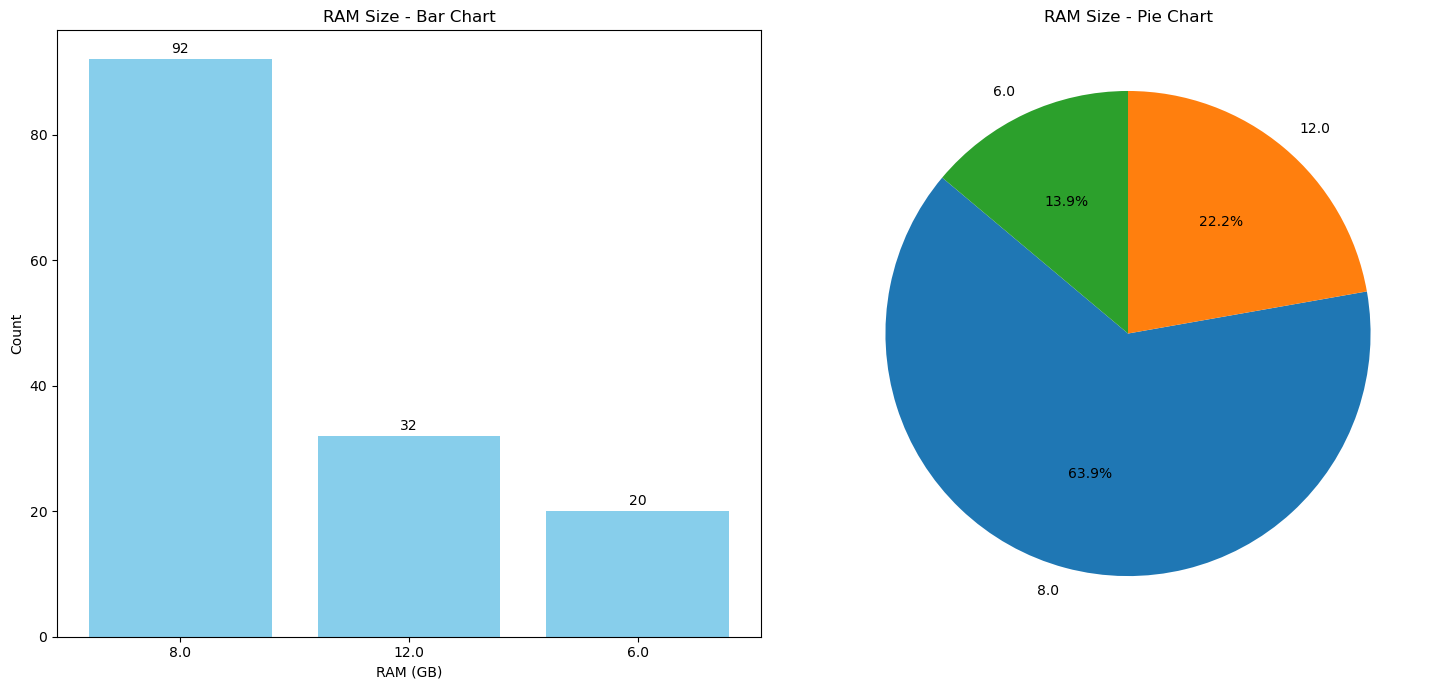

In [29]:
ram_counts = df['RAM'].value_counts()
ram_labels=ram_counts.index.astype(str)
plt.figure(figsize=(15,7))

plt.subplot(1,2,1)
plt.bar(ram_labels, ram_counts.values, color='skyblue')
plt.title('RAM Size - Bar Chart')
plt.xlabel('RAM (GB)')
plt.ylabel('Count')
for i, count in enumerate(ram_counts.values):
    plt.text(i, count + 0.5, str(count), ha='center', va='bottom')
    
plt.subplot(1,2,2)
plt.pie(ram_counts,labels=ram_counts.index , autopct='%1.1f%%', startangle=140)
plt.title('RAM Size - Pie Chart')
plt.tight_layout()
plt.show()

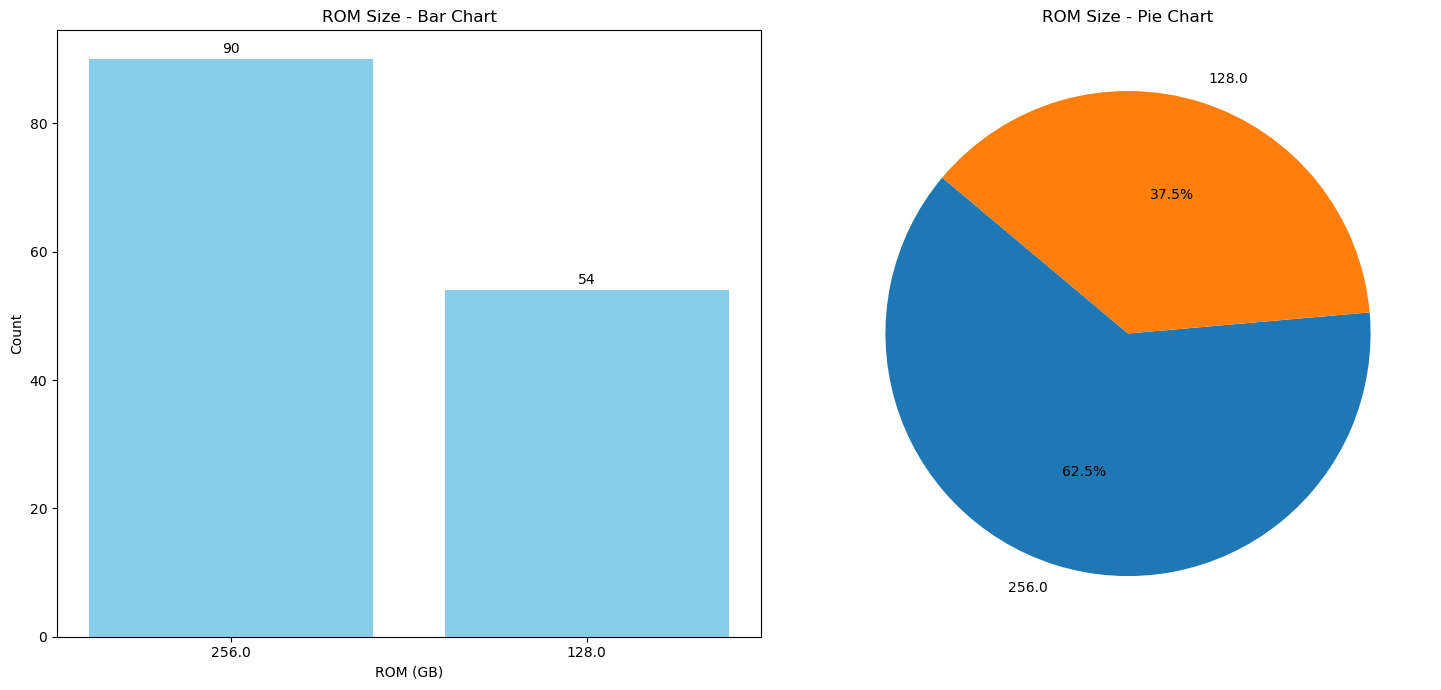

In [30]:
rom_counts = df['ROM'].value_counts()
rom_labels=rom_counts.index.astype(str)
plt.figure(figsize=(15,7))

plt.subplot(1,2,1)
plt.bar(rom_labels, rom_counts.values, color='skyblue')
plt.title('ROM Size - Bar Chart')
plt.xlabel('ROM (GB)')
plt.ylabel('Count')
for i, count in enumerate(rom_counts.values):
    plt.text(i, count + 0.5, str(count), ha='center', va='bottom')
    
plt.subplot(1,2,2)
plt.pie(rom_counts,labels=rom_counts.index , autopct='%1.1f%%', startangle=140)
plt.title('ROM Size - Pie Chart')
plt.tight_layout()
plt.show()

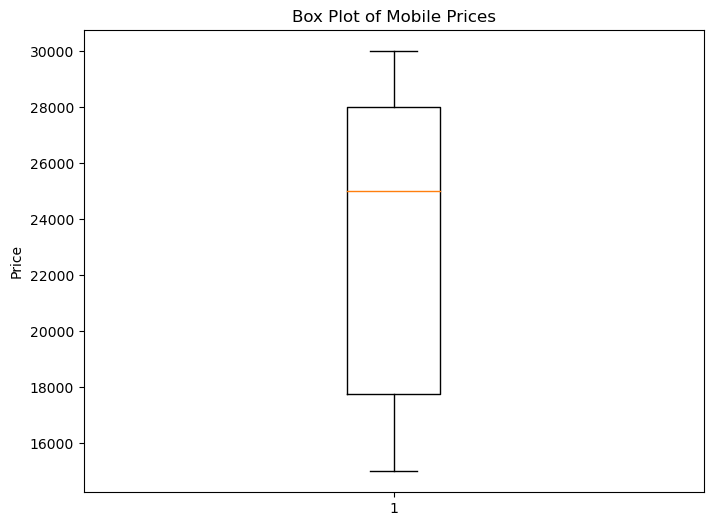

In [31]:


plt.figure(figsize=(8,6))
plt.boxplot(df['Mobile Price'].dropna())  
plt.title('Box Plot of Mobile Prices')
plt.ylabel('Price')
plt.show()

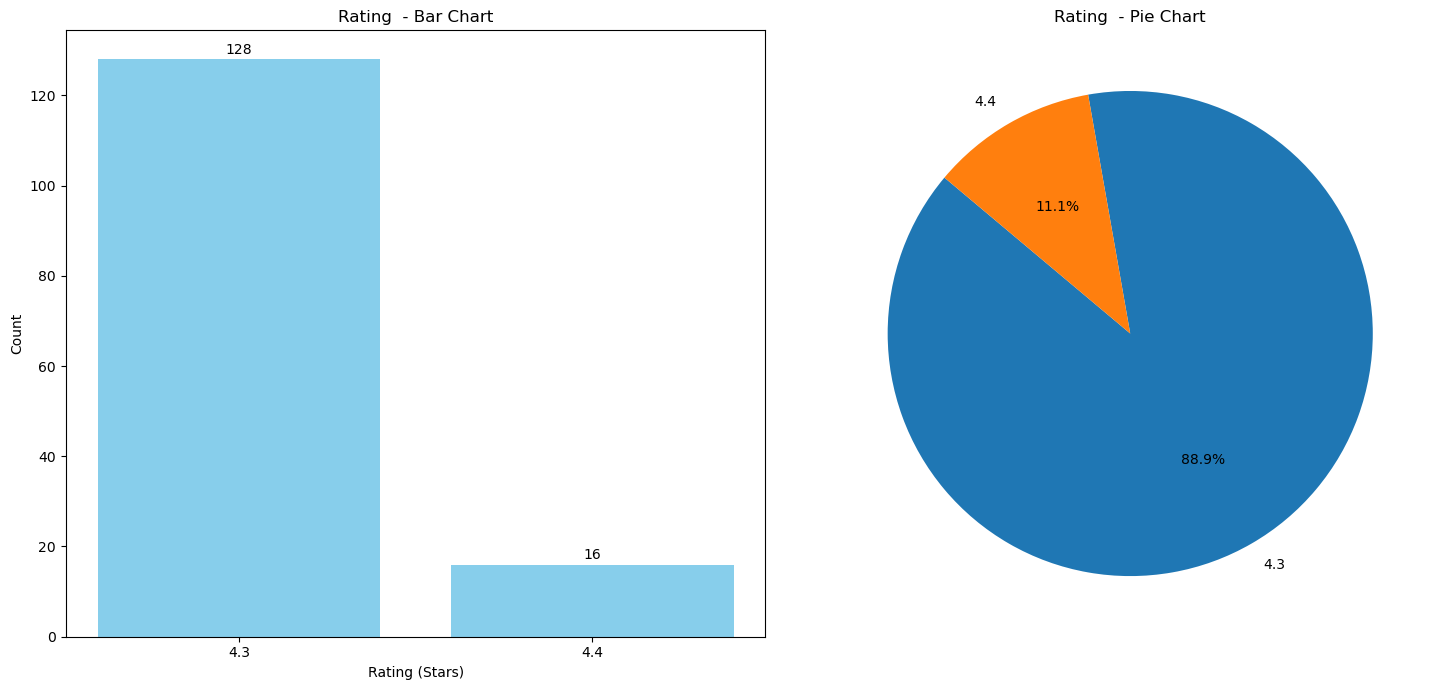

In [32]:
rating_counts = df['Rating'].value_counts()
rating_labels=rating_counts.index.astype(str)
plt.figure(figsize=(15,7))

plt.subplot(1,2,1)
plt.bar(rating_labels, rating_counts.values, color='skyblue')
plt.title('Rating  - Bar Chart')
plt.xlabel('Rating (Stars)')
plt.ylabel('Count')
for i, count in enumerate(rating_counts.values):
    plt.text(i, count + 0.5, str(count), ha='center', va='bottom')
    
plt.subplot(1,2,2)
plt.pie(rating_counts,labels=rating_counts.index , autopct='%1.1f%%', startangle=140)
plt.title('Rating  - Pie Chart')
plt.tight_layout()
plt.show()

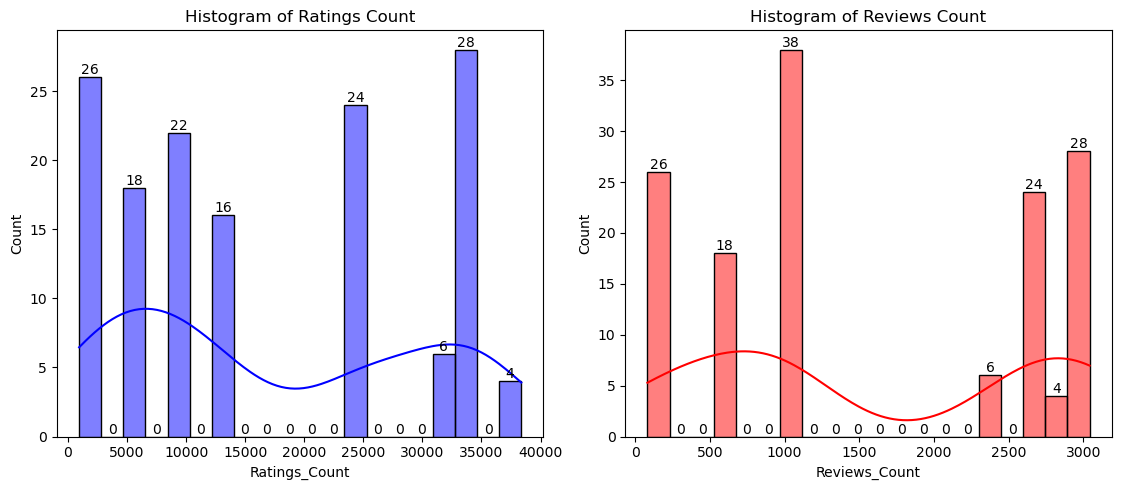

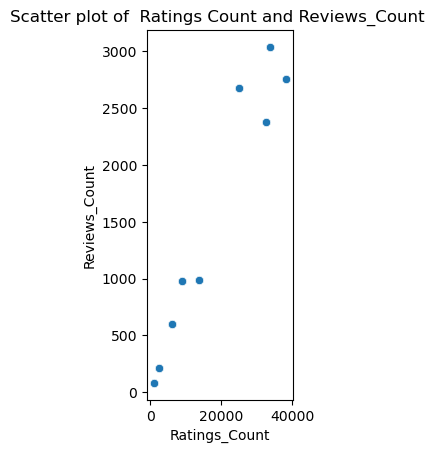

In [57]:


plt.figure(figsize=(17,5))


plt.subplot(1,3,1)
sns.histplot(df['Ratings_Count'].dropna(), bins=20, kde=True, color='b')
plt.title('Histogram of Ratings Count')
for p in plt.gca().patches:
    plt.text(p.get_x() + p.get_width()/2, p.get_height(), int(p.get_height()), ha='center', va='bottom')


plt.subplot(1,3,2)
sns.histplot(df['Reviews_Count'].dropna(), bins=20, kde=True, color='r')
plt.title('Histogram of Reviews Count')
for p in plt.gca().patches:
    plt.text(p.get_x() + p.get_width()/2, p.get_height(), int(p.get_height()), ha='center', va='bottom')
plt.tight_layout()
plt.show()

plt.subplot(1,3,2)

plt.title('Scatter plot of  Ratings Count and Reviews_Count ')
sns.scatterplot(x='Ratings_Count', y='Reviews_Count', data=df)
plt.show()

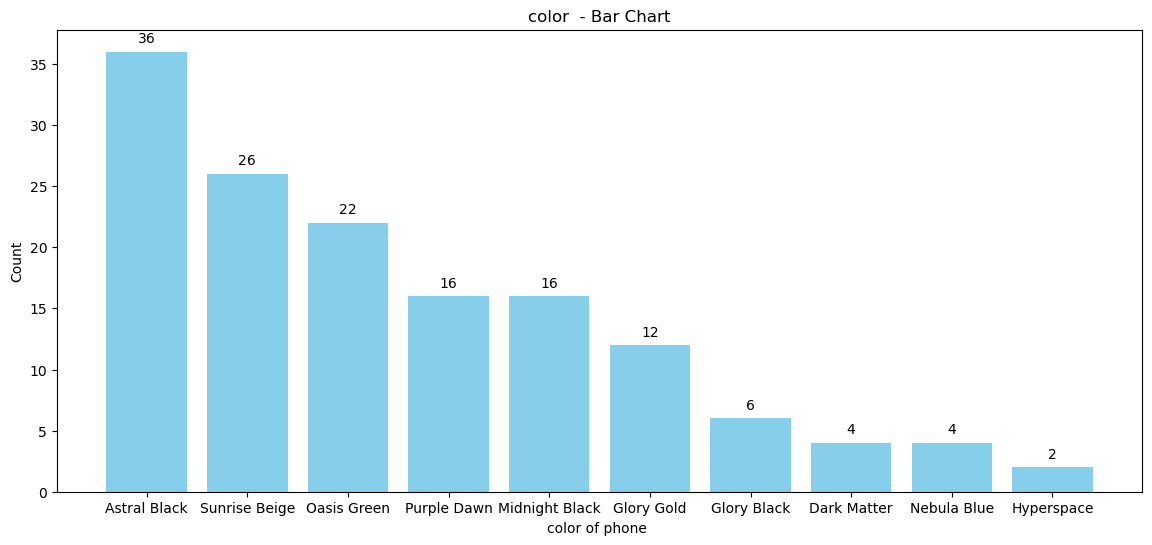

In [34]:
plt.figure(figsize=(14,6))
color_count=df['Color'].value_counts()
color_label=color_count.index.astype(str)
plt.bar(color_label, color_count.values, color='skyblue')
plt.title('color  - Bar Chart')
plt.xlabel('color of phone ')
plt.ylabel('Count')
for i, count in enumerate(color_count.values):
    plt.text(i, count + 0.5, str(count), ha='center', va='bottom')
plt.show()

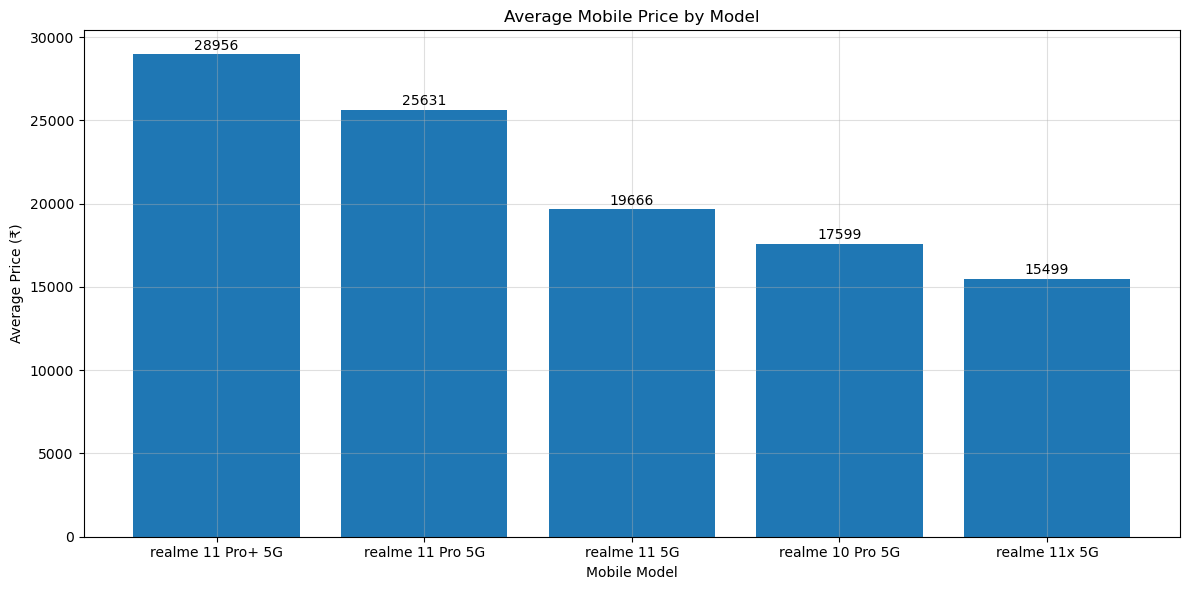

In [102]:
avg_price = df.groupby('Mobile Name')['Mobile Price'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
bars = plt.bar(avg_price.index, avg_price.values)  

plt.title('Average Mobile Price by Model')
plt.xlabel('Mobile Model')
plt.ylabel('Average Price (₹)')
plt.grid(alpha=0.4)

for bar in bars: 
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 100, f'{height:.0f}', 
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


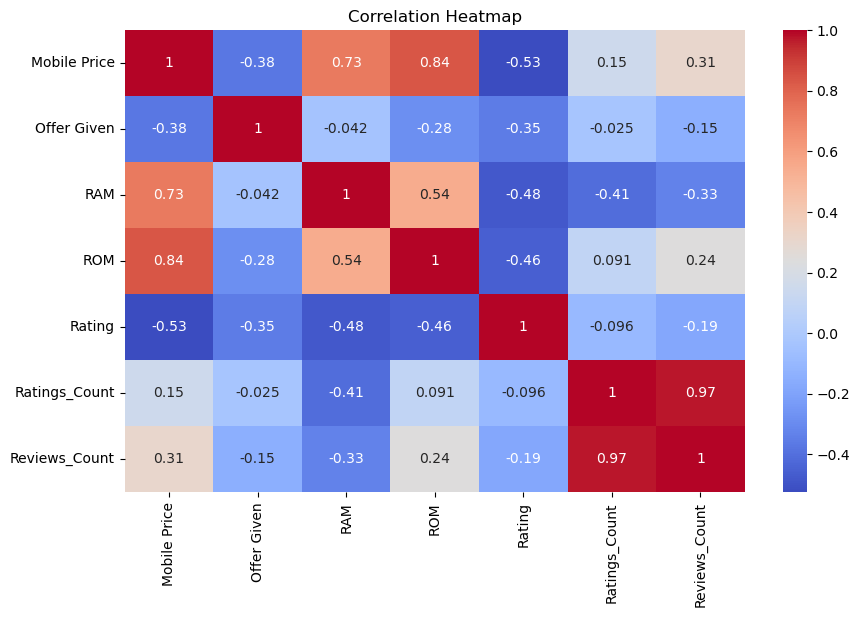

In [69]:
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

<AxesSubplot:xlabel='Battery', ylabel='Mobile Price'>

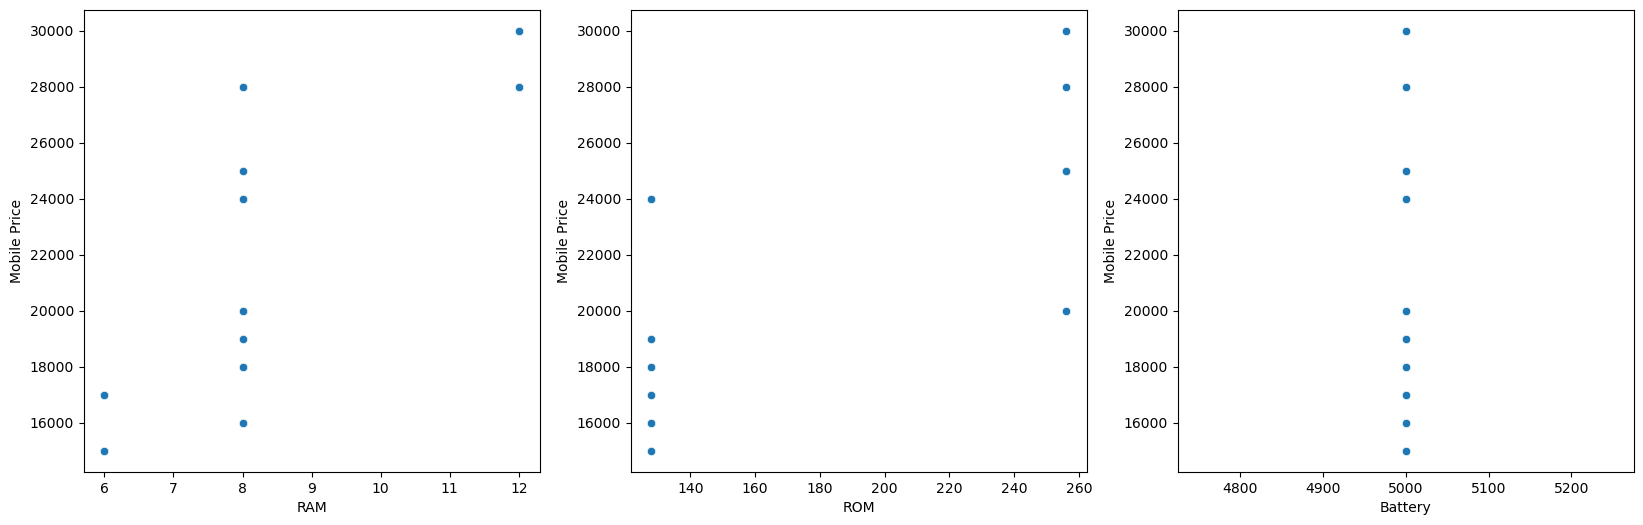

In [54]:
plt.figure(figsize=(20,6))
plt.subplot(1,3,1)
plt.title('Price Vs RAM')
sns.scatterplot(x='RAM', y='Mobile Price', data=df)
plt.subplot(1,3,2)
plt.title('Price Vs ROM')
sns.scatterplot(x='ROM', y='Mobile Price', data=df)
plt.subplot(1,3,3)
plt.title('Price Vs Battery')
sns.scatterplot(x='Battery', y='Mobile Price', data=df)

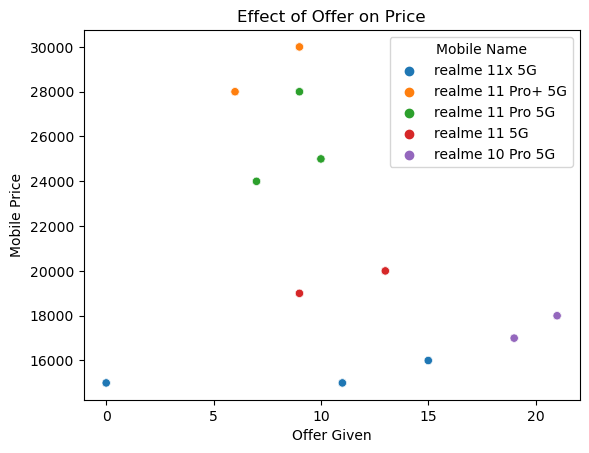

In [81]:
sns.scatterplot(x='Offer Given', y='Mobile Price', hue='Mobile Name', data=df)
plt.title('Effect of Offer on Price')
plt.show()


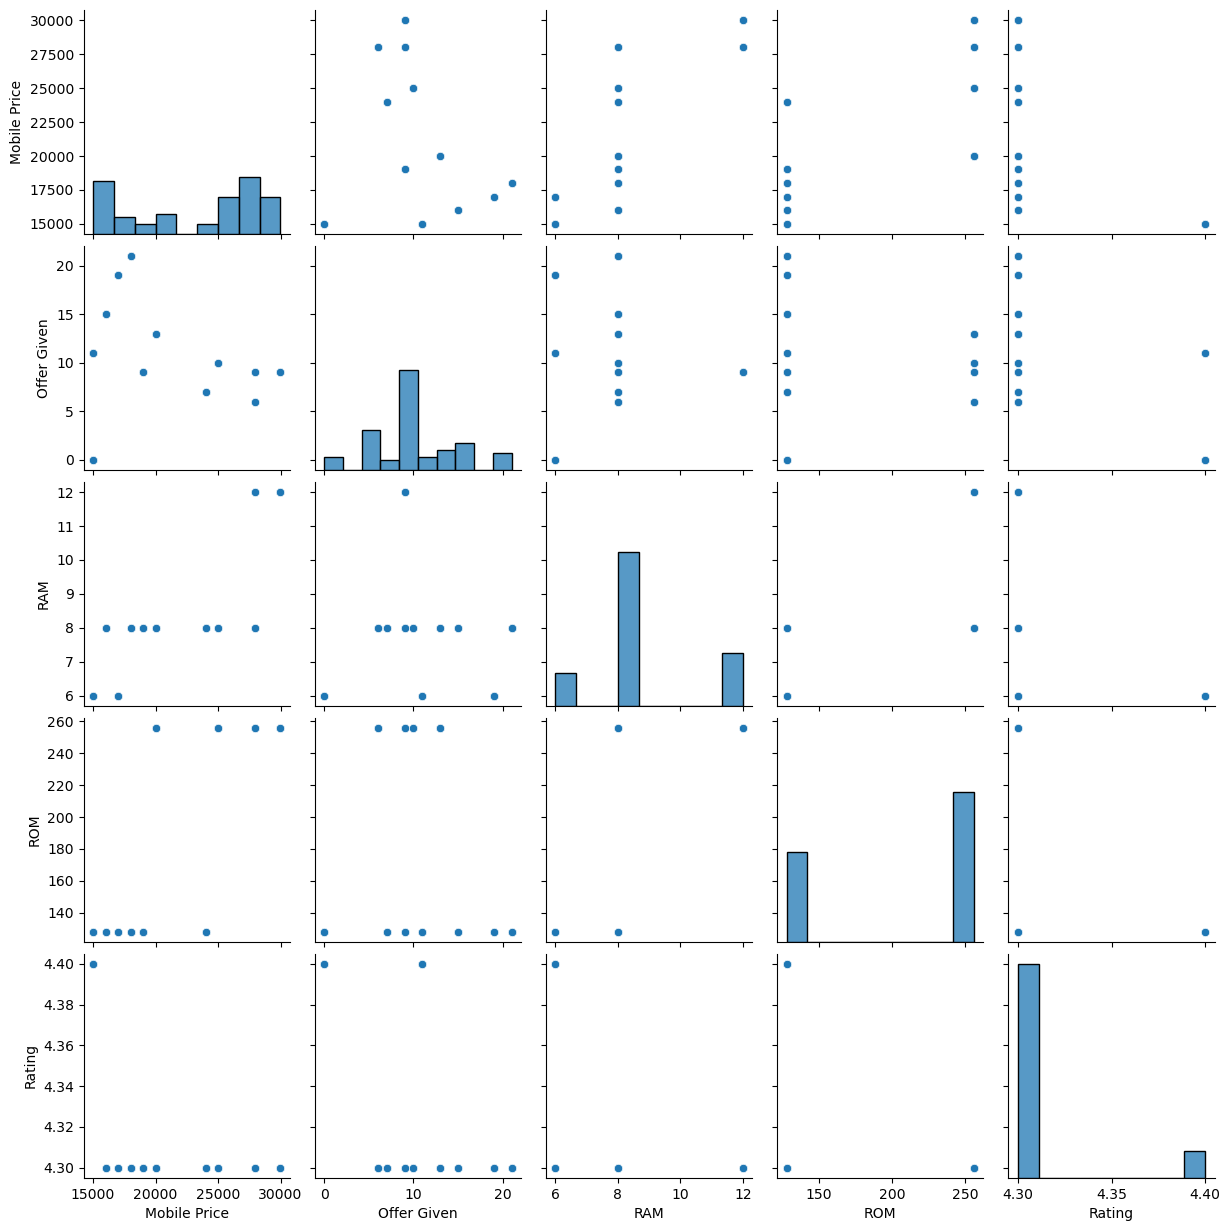

In [105]:
sns.pairplot(df[['Mobile Price', 'Offer Given', 'RAM', 'ROM', 'Rating']])